#### Test de algunos modelos

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
# from ydata_profiling import ProfileReport

c:\Users\drkfa\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("dataset_no_outliers.csv")

# Crear el reporte
#profile = ProfileReport(df, title="Reporte del Dataset Unificado", explorative=True)

# Guardarlo como archivo HTML
#profile.to_file("dataset.html")

In [3]:
# X: todas las columnas menos la última
X = df.iloc[:, :-1]

# y: última columna
y = df.iloc[:, -1]


In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Modelos de Regresión

Regresión lineal (solo freight_value)
R²: 0.22515260843989737
MAE: 0.19106081667792424
RMSE: 0.37583994297430473


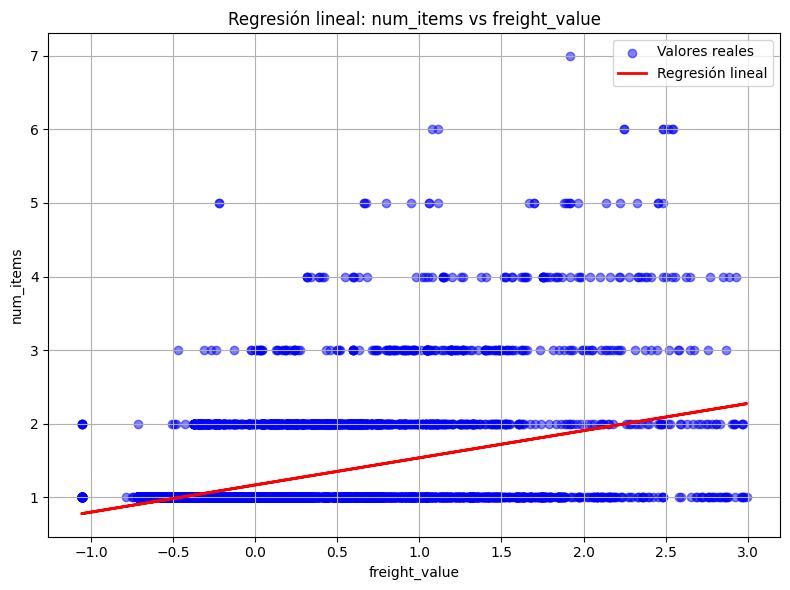

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


#  Extraer solo la columna freight_value de los conjuntos ya divididos
X_train_simple = X_train[['freight_value']]
X_test_simple = X_test[['freight_value']]

#  Crear y entrenar modelo
lr_simple = LinearRegression()
lr_simple.fit(X_train_simple, y_train)

#  Predecir
y_pred_simple = lr_simple.predict(X_test_simple)

#  Evaluar
print("Regresión lineal (solo freight_value)")
print("R²:", r2_score(y_test, y_pred_simple))
print("MAE:", mean_absolute_error(y_test, y_pred_simple))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_simple)))

# Graficar
plt.figure(figsize=(8, 6))
plt.scatter(X_test_simple, y_test, color='blue', alpha=0.5, label='Valores reales')
plt.plot(X_test_simple, y_pred_simple, color='red', linewidth=2, label='Regresión lineal')
plt.xlabel('freight_value')
plt.ylabel('num_items')
plt.title('Regresión lineal: num_items vs freight_value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


R²: 0.3460387501182226
MAE: 0.1926324568659545
RMSE: 0.34527954718864556


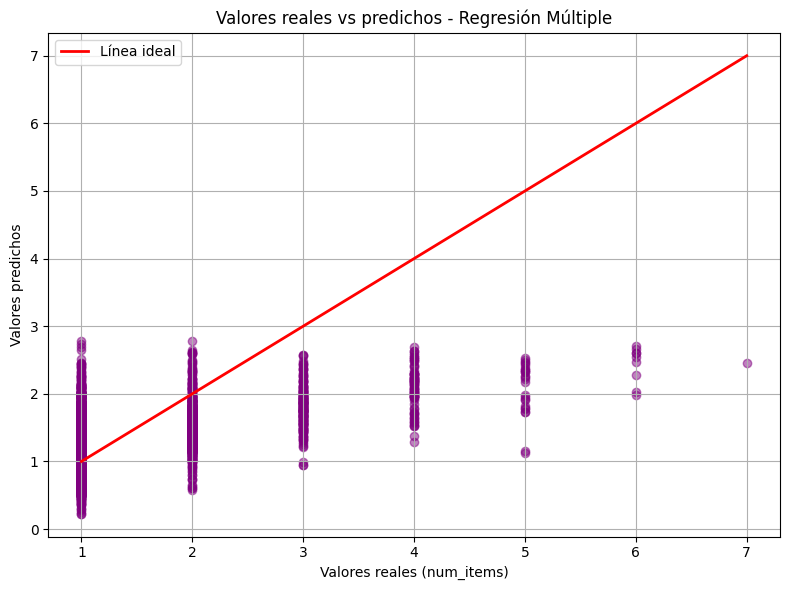

In [6]:

# Crear y entrenar el modelo
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predecir y evaluar
y_pred = lr.predict(X_test)

print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

# Graficar
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2, label='Línea ideal')
plt.xlabel('Valores reales (num_items)')
plt.ylabel('Valores predichos')
plt.title('Valores reales vs predichos - Regresión Múltiple')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Regresión Polinomial (grado 3)
R²: 0.23517344682146235
MAE: 0.17195292662556466
RMSE: 0.37340172894870904


c:\Users\drkfa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


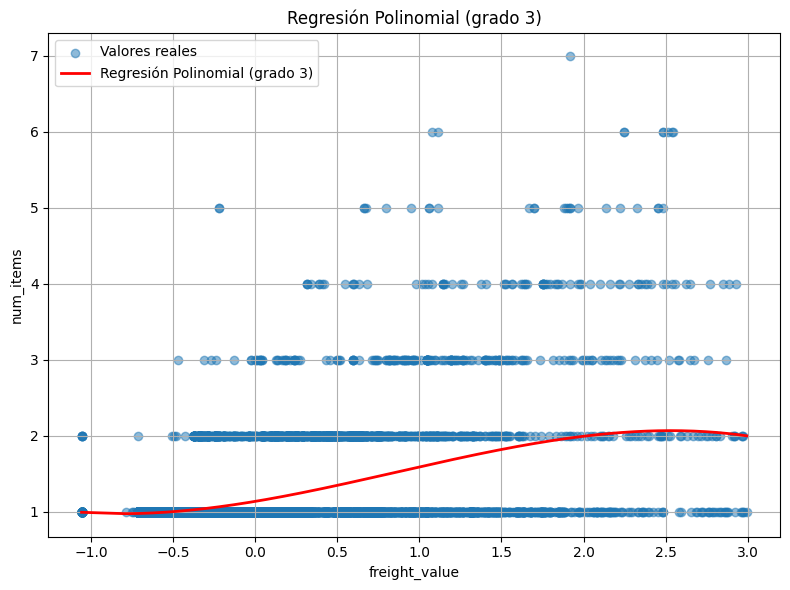

In [7]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Crear pipeline con grado polinomial 
degree = 3
poly_model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
poly_model.fit(X_train_simple, y_train)

# 4. Predecir
y_pred = poly_model.predict(X_test_simple)

# 5. Evaluar
print(f"Regresión Polinomial (grado {degree})")
print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

# Graficar
x_vals = X_test_simple.sort_values(by='freight_value')
x_plot = x_vals['freight_value'].values.reshape(-1, 1)
y_plot = poly_model.predict(x_plot)

plt.figure(figsize=(8, 6))
plt.scatter(X_test_simple, y_test, label='Valores reales', alpha=0.5)
plt.plot(x_plot, y_plot, color='red', linewidth=2, label=f'Regresión Polinomial (grado {degree})')
plt.xlabel('freight_value')
plt.ylabel('num_items')
plt.title(f'Regresión Polinomial (grado {degree})')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

R²: 0.37590647345874484
MAE: 0.0666190774232544
RMSE: 0.3373025968485127


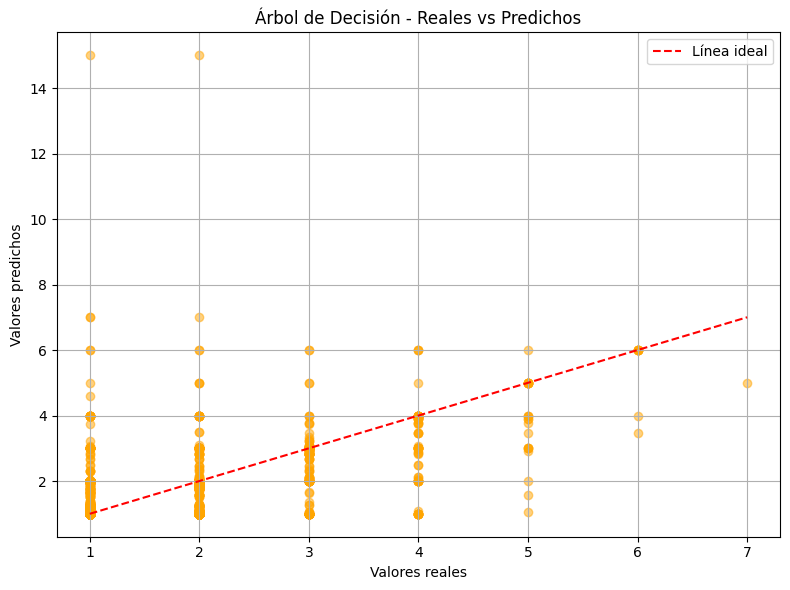

In [8]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Entrenar el modelo
tree = DecisionTreeRegressor(random_state=42, max_depth=15)  
tree.fit(X_train, y_train)

# 2. Predecir
y_pred_tree = tree.predict(X_test)

# 3. Evaluar
print("R²:", r2_score(y_test, y_pred_tree))
print("MAE:", mean_absolute_error(y_test, y_pred_tree))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_tree)))

# Graficar
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_tree, alpha=0.5, color='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Línea ideal')
plt.xlabel('Valores reales')
plt.ylabel('Valores predichos')
plt.title('Árbol de Decisión - Reales vs Predichos')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Random Forest Regressor
R²: 0.7594372292204847
MAE: 0.06151861155514957
RMSE: 0.2094156115924151


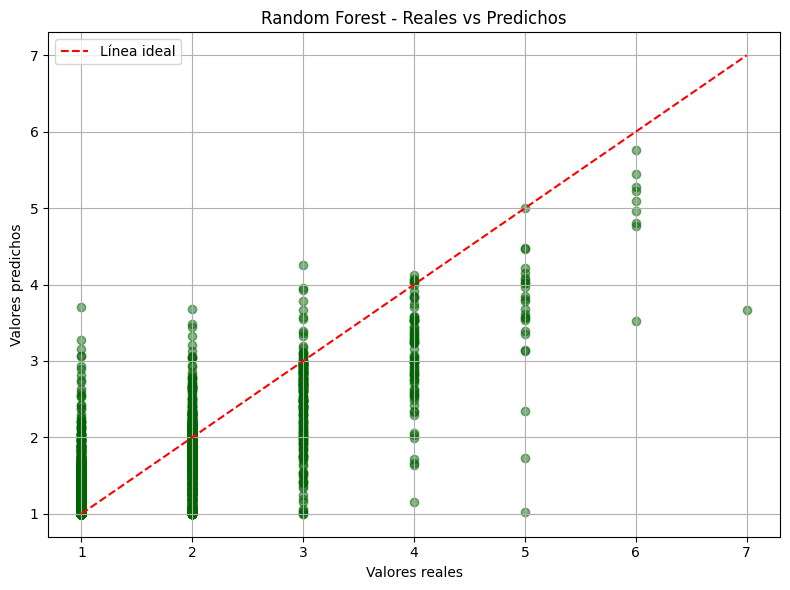

In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Crear y entrenar el modelo
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 2. Predecir
y_pred_rf = rf.predict(X_test)

# 3. Evaluar
print("Random Forest Regressor")
print("R²:", r2_score(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

# Graficar
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.5, color='darkgreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Línea ideal')
plt.xlabel('Valores reales')
plt.ylabel('Valores predichos')
plt.title('Random Forest - Reales vs Predichos')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


SVR (solo freight_value)
R²: 0.20327758158238118
MAE: 0.15395552229049245
RMSE: 0.3811082626888029


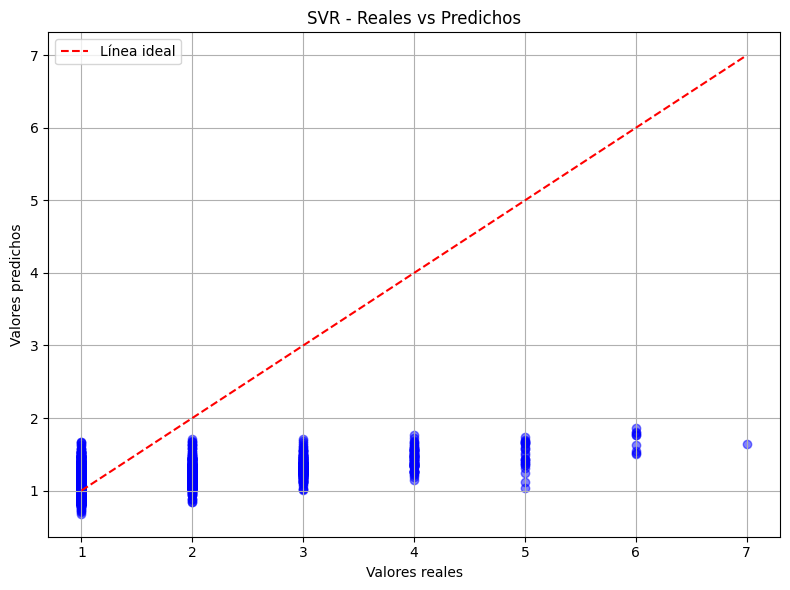

In [10]:
from sklearn.svm import SVR

svr_model = SVR(kernel='rbf')

svr_model.fit(X_train, y_train)

svr_pred = svr_model.predict(X_test)

# 5. Evaluar
print("SVR (solo freight_value)")
print("R²:", r2_score(y_test, svr_pred))
print("MAE:", mean_absolute_error(y_test, svr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, svr_pred)))

# Graficar
plt.figure(figsize=(8, 6))
plt.scatter(y_test, svr_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Línea ideal')
plt.xlabel('Valores reales')
plt.ylabel('Valores predichos')
plt.title('SVR - Reales vs Predichos')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Modelos de Clasificación

In [11]:
y.value_counts(normalize=True)


num_items
1.0     0.905535
2.0     0.075796
3.0     0.012480
4.0     0.004042
5.0     0.001176
6.0     0.000856
7.0     0.000091
15.0    0.000011
8.0     0.000011
Name: proportion, dtype: float64

C:\Users\drkfa\AppData\Local\Temp\ipykernel_11620\1507481775.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='num_items', data=df, palette="Blues")


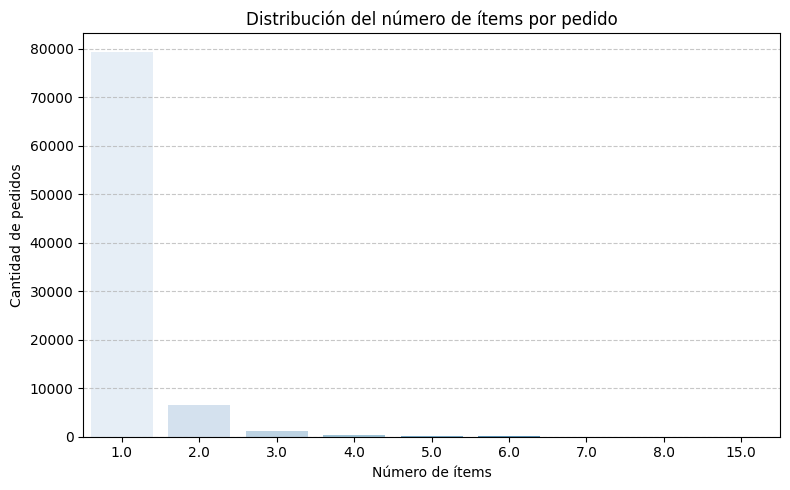

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(x='num_items', data=df, palette="Blues")

plt.title("Distribución del número de ítems por pedido")
plt.xlabel("Número de ítems")
plt.ylabel("Cantidad de pedidos")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


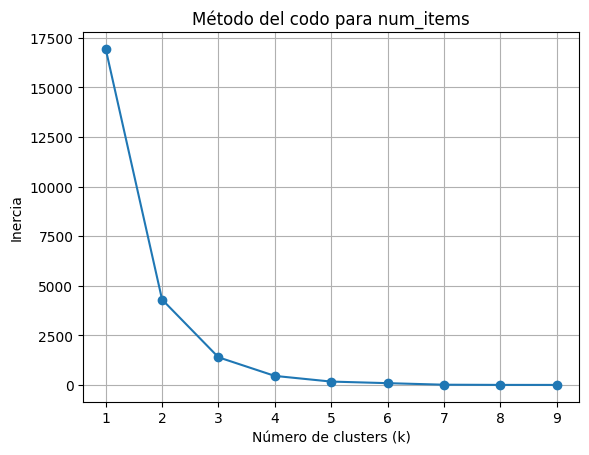

In [13]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Vector de solo num_items
X_cluster = df[['num_items']]

# Probar diferentes valores de k
inertias = []
ks = range(1, 10)

for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_cluster)
    inertias.append(kmeans.inertia_)

# Graficar el método del codo
plt.plot(ks, inertias, marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del codo para num_items')
plt.grid(True)
plt.show()


In [14]:
# Crear una nueva columna con clases agrupadas
def clasificar_items(n):
    if n == 1:
        return '1'
    elif n == 2:
        return '2'
    else:
        return '3+'

df['num_items_class'] = df['num_items'].apply(clasificar_items)


In [15]:
df['num_items_class'].value_counts(normalize=True)


num_items_class
1     0.905535
2     0.075796
3+    0.018669
Name: proportion, dtype: float64

In [16]:
X_classification = df.drop(columns=['num_items', 'num_items_class'])  
y_classification = df['num_items_class']


In [17]:
# Ver cuántos ejemplos hay por clase
print(y_classification.value_counts())

# Filtrar para obtener solo aquellas clases que tengan al menos 2 instancias
valid_classes = y_classification.value_counts()[y_classification.value_counts() > 1].index
mask = y_classification.isin(valid_classes)

X_classification_filtered = X_classification[mask]
y_classification_filtered = y_classification[mask]

from sklearn.model_selection import train_test_split

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_classification_filtered, y_classification_filtered, test_size=0.2, stratify=y_classification_filtered, random_state=42
)

num_items_class
1     79304
2      6638
3+     1635
Name: count, dtype: int64


c:\Users\drkfa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


=== Logistic Regression ===
              precision    recall  f1-score   support

           1       0.99      0.90      0.94     15861
           2       0.39      0.69      0.50      1328
          3+       0.39      0.84      0.53       327

    accuracy                           0.88     17516
   macro avg       0.59      0.81      0.66     17516
weighted avg       0.93      0.88      0.90     17516

F1-Score (macro): 0.6553859569035058
Precision (macro): 0.5867921739111825
Recall (macro): 0.8097844411717515


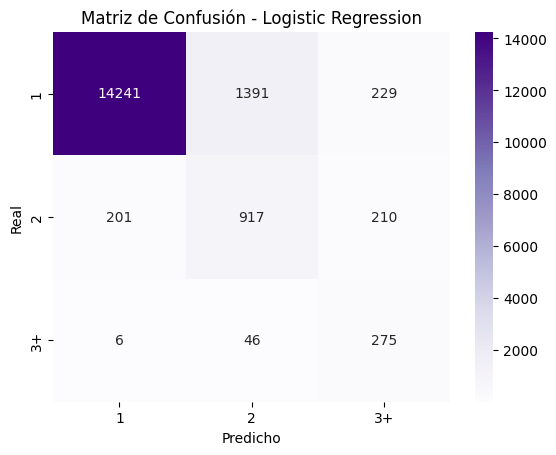

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score

# Aplicar solo al conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_cls, y_train_cls)

model_lr = LogisticRegression(max_iter=1000)  
model_lr.fit(X_train_res, y_train_res)

# Evaluación
y_pred_lr = model_lr.predict(X_test_cls)

print("=== Logistic Regression ===")
print(classification_report(y_test_cls, y_pred_lr))

# Macro average: todas las clases igual de importantes
f1_macro = f1_score(y_test_cls, y_pred_lr, average='macro')
precision_macro = precision_score(y_test_cls, y_pred_lr, average='macro')
recall_macro = recall_score(y_test_cls, y_pred_lr, average='macro')

print("F1-Score (macro):", f1_macro)
print("Precision (macro):", precision_macro)
print("Recall (macro):", recall_macro)

# Matriz de confusión
sns.heatmap(confusion_matrix(y_test_cls, y_pred_lr), annot=True, fmt='d', cmap='Purples',
            xticklabels=model_lr.classes_, yticklabels=model_lr.classes_)
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Logistic Regression")
plt.show()

Decision Tree
              precision    recall  f1-score   support

           1       0.98      0.95      0.96     15861
           2       0.57      0.73      0.64      1328
          3+       0.44      0.67      0.53       327

    accuracy                           0.93     17516
   macro avg       0.66      0.78      0.71     17516
weighted avg       0.94      0.93      0.93     17516

F1-Score promedio: 0.7098648525201079
Precision (macro): 0.66172702498516
Recall (macro): 0.7809746819657281


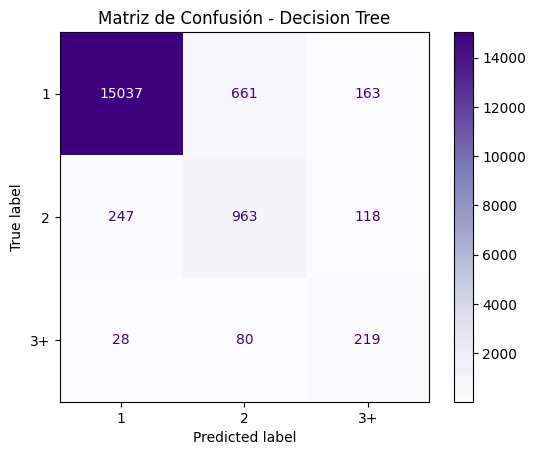

In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Aplicar solo al conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_cls, y_train_cls)

# Entrenar el modelo
model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train_res, y_train_res)

# Predecir
y_pred_dt = model_dt.predict(X_test_cls)

# Reporte de clasificación
print("Decision Tree")
print(classification_report(y_test_cls, y_pred_dt))

# F1-Score general
f1_macro = f1_score(y_test_cls, y_pred_dt, average='macro')
precision_macro = precision_score(y_test_cls, y_pred_dt, average='macro')
recall_macro = recall_score(y_test_cls, y_pred_dt, average='macro')

print("F1-Score promedio:", f1_macro)
print("Precision (macro):", precision_macro)
print("Recall (macro):", recall_macro)


# Matriz de confusión
cm = confusion_matrix(y_test_cls, y_pred_dt, labels=model_dt.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_dt.classes_)
disp.plot(cmap='Purples')
plt.title("Matriz de Confusión - Decision Tree")
plt.show()


In [20]:
y_train_res.value_counts()

num_items_class
1     63443
2     63443
3+    63443
Name: count, dtype: int64

 Random Forest
              precision    recall  f1-score   support

           1       0.99      0.97      0.98     15861
           2       0.71      0.79      0.75      1328
          3+       0.65      0.69      0.67       327

    accuracy                           0.95     17516
   macro avg       0.78      0.82      0.80     17516
weighted avg       0.96      0.95      0.96     17516

 F1-Score macro: 0.8
Precision (macro): 0.7814189162433176
Recall (macro): 0.8207964862680036


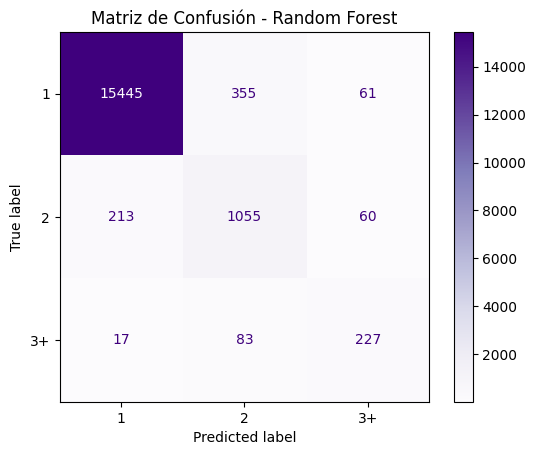

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Aplicar solo al conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_cls, y_train_cls)

# Entrenar modelo
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train_res, y_train_res)

# Predicciones
y_pred_rf = model_rf.predict(X_test_cls)

# Reporte de clasificación
print(" Random Forest")
print(classification_report(y_test_cls, y_pred_rf))

# F1-Score promedio (macro)
f1_macro = f1_score(y_test_cls, y_pred_rf, average='macro')
precision_macro = precision_score(y_test_cls, y_pred_rf, average='macro')
recall_macro = recall_score(y_test_cls, y_pred_rf, average='macro')

print(" F1-Score macro:", round(f1_macro, 3))
print("Precision (macro):", precision_macro)
print("Recall (macro):", recall_macro)

# Matriz de confusión
cm = confusion_matrix(y_test_cls, y_pred_rf, labels=model_rf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_rf.classes_)
disp.plot(cmap="Purples")
plt.title("Matriz de Confusión - Random Forest")
plt.show()



SVC
              precision    recall  f1-score   support

           1       0.99      0.90      0.94     15861
           2       0.44      0.75      0.55      1328
          3+       0.37      0.81      0.51       327

    accuracy                           0.89     17516
   macro avg       0.60      0.82      0.67     17516
weighted avg       0.93      0.89      0.91     17516

F1-Score promedio: 0.6682354600609076
Precision (macro): 0.5983592350251042
Recall (macro): 0.8214541446105607


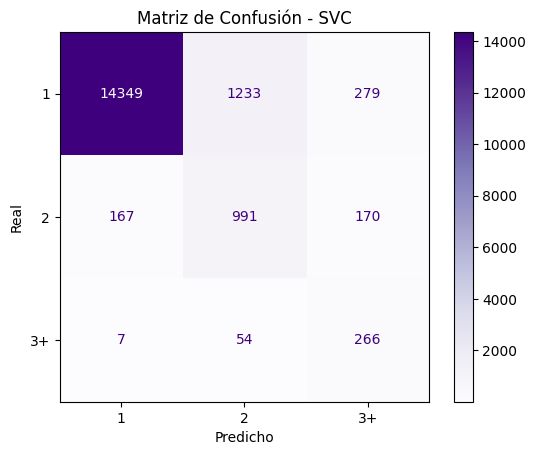

In [22]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
import matplotlib.pyplot as plt

# Aplicar solo al conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_cls, y_train_cls)

# Entrenar el modelo
model_svc = SVC(random_state=42)
model_svc.fit(X_train_res, y_train_res)

# Predecir
y_pred_svc = model_svc.predict(X_test_cls)

# Imprimir reporte
print("SVC")
print(classification_report(y_test_cls, y_pred_svc))

# macro promedio
f1_macro = f1_score(y_test_cls, y_pred_svc, average='macro')
precision_macro = precision_score(y_test_cls, y_pred_svc, average='macro')
recall_macro = recall_score(y_test_cls, y_pred_svc, average='macro')

print("F1-Score promedio:", f1_macro)
print("Precision (macro):", precision_macro)
print("Recall (macro):", recall_macro)

# Matriz de confusión
cm = confusion_matrix(y_test_cls, y_pred_svc, labels=model_svc.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_svc.classes_)
disp.plot(cmap="Purples")
plt.title("Matriz de Confusión - SVC")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()



In [23]:
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier

# Aplicar solo al conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_cls, y_train_cls)

model_knn = KNeighborsClassifier(n_neighbors=3)
model_knn.fit(X_train_bal, y_train_bal)

y_pred_knn = model_knn.predict(X_test_cls)
print("KNN con SMOTE")
print(classification_report(y_test_cls, y_pred_knn))

f1_macro = f1_score(y_test_cls, y_pred_knn, average='macro')
precision_macro = precision_score(y_test_cls, y_pred_knn, average='macro')
recall_macro = recall_score(y_test_cls, y_pred_knn, average='macro')

print("F1-Score promedio:", f1_macro)
print("Precision (macro):", precision_macro)
print("Recall (macro):", recall_macro)


KNN con SMOTE
              precision    recall  f1-score   support

           1       0.95      0.84      0.89     15861
           2       0.18      0.41      0.25      1328
          3+       0.24      0.37      0.29       327

    accuracy                           0.80     17516
   macro avg       0.46      0.54      0.48     17516
weighted avg       0.88      0.80      0.83     17516

F1-Score promedio: 0.47820199218123155
Precision (macro): 0.4562107978794143
Recall (macro): 0.5401744135716396


### Modelos con Validación Cruzada

Regresión

In [24]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model = RandomForestRegressor(random_state=42)

# RMSE (con signo positivo)
rmse_scores = -cross_val_score(model, X_train, y_train, cv=5,
                            scoring='neg_root_mean_squared_error')
mae_scores = -cross_val_score(model, X_train, y_train, cv=5,
                            scoring='neg_mean_absolute_error')
r2_scores = cross_val_score(model, X_train, y_train, cv=5,
                            scoring='r2')

# Mostrar resultados
print("=== Random Forest Regressor (5-Fold CV) ===")
print(f"RMSE promedio: {rmse_scores.mean():.4f}")
print(f"MAE promedio: {mae_scores.mean():.4f}")
print(f"R² promedio: {r2_scores.mean():.4f}")


=== Random Forest Regressor (5-Fold CV) ===
RMSE promedio: 0.2426
MAE promedio: 0.0670
R² promedio: 0.6997


In [25]:
from sklearn.tree import DecisionTreeRegressor

model_dt = DecisionTreeRegressor(random_state=42)

rmse_dt = -cross_val_score(model_dt, X_train, y_train, cv=5,
                        scoring='neg_root_mean_squared_error')
mae_dt = -cross_val_score(model_dt, X_train, y_train, cv=5,
                        scoring='neg_mean_absolute_error')
r2_dt = cross_val_score(model_dt, X_train, y_train, cv=5,
                        scoring='r2')

print("=== Decision Tree Regressor (5-Fold CV) ===")
print(f"RMSE promedio: {rmse_dt.mean():.4f}")
print(f"MAE promedio: {mae_dt.mean():.4f}")
print(f"R² promedio: {r2_dt.mean():.4f}")


=== Decision Tree Regressor (5-Fold CV) ===
RMSE promedio: 0.3605
MAE promedio: 0.0713
R² promedio: 0.3353


In [26]:
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()

rmse_lr = -cross_val_score(model_lr, X_train, y_train, cv=5,
                        scoring='neg_root_mean_squared_error')
mae_lr = -cross_val_score(model_lr, X_train, y_train, cv=5,
                        scoring='neg_mean_absolute_error')
r2_lr = cross_val_score(model_lr, X_train, y_train, cv=5,
                        scoring='r2')

print("=== Linear Regression (5-Fold CV) ===")
print(f"RMSE promedio: {rmse_lr.mean():.4f}")
print(f"MAE promedio: {mae_lr.mean():.4f}")
print(f"R² promedio: {r2_lr.mean():.4f}")


=== Linear Regression (5-Fold CV) ===
RMSE promedio: 0.3621
MAE promedio: 0.1963
R² promedio: 0.3312


Clasificación

In [27]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Función de evaluación
def evaluate_classifier_cv(model, model_name, X, y):
    pipe = Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('clf', model)
    ])
    
    f1 = cross_val_score(pipe, X, y, cv=5, scoring='f1_macro')
    precision = cross_val_score(pipe, X, y, cv=5, scoring='precision_macro')
    recall = cross_val_score(pipe, X, y, cv=5, scoring='recall_macro')
    
    print(f"=== {model_name} (5-Fold CV con SMOTE) ===")
    print(f"F1-score macro promedio: {f1.mean():.4f}")
    print(f"Precision macro promedio: {precision.mean():.4f}")
    print(f"Recall macro promedio: {recall.mean():.4f}")
    print()


In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

# Evaluaciones
evaluate_classifier_cv(RandomForestClassifier(random_state=42), "Random Forest", X_train_cls, y_train_cls)
evaluate_classifier_cv(DecisionTreeClassifier(random_state=42), "Decision Tree", X_train_cls, y_train_cls)
evaluate_classifier_cv(LogisticRegression(max_iter=1000, random_state=42), "Logistic Regression", X_train_cls, y_train_cls)


=== Random Forest (5-Fold CV con SMOTE) ===
F1-score macro promedio: 0.7839
Precision macro promedio: 0.7664
Recall macro promedio: 0.8037

=== Decision Tree (5-Fold CV con SMOTE) ===
F1-score macro promedio: 0.6989
Precision macro promedio: 0.6528
Recall macro promedio: 0.7661



c:\Users\drkfa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\drkfa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/st

=== Logistic Regression (5-Fold CV con SMOTE) ===
F1-score macro promedio: 0.6342
Precision macro promedio: 0.5707
Recall macro promedio: 0.7804



c:\Users\drkfa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Red Neuronal

Red Neuronal - MLP
              precision    recall  f1-score   support

           1       0.99      0.94      0.96     15861
           2       0.52      0.76      0.62      1328
          3+       0.41      0.61      0.49       327

    accuracy                           0.92     17516
   macro avg       0.64      0.77      0.69     17516
weighted avg       0.94      0.92      0.93     17516

F1-Score promedio: 0.6886128061813565
Precision (macro): 0.6366317395208784
Recall (macro): 0.7705154746779656


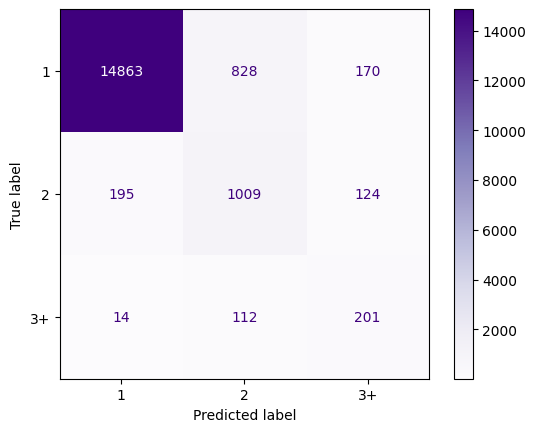

In [29]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42)

mlp.fit(X_train_res, y_train_res)
y_pred_mlp = mlp.predict(X_test_cls)

print("Red Neuronal - MLP")
print(classification_report(y_test_cls, y_pred_mlp))

f1_macro = f1_score(y_test_cls, y_pred_mlp, average='macro')
precision_macro = precision_score(y_test_cls, y_pred_mlp, average='macro')
recall_macro = recall_score(y_test_cls, y_pred_mlp, average='macro')

print("F1-Score promedio:", f1_macro)
print("Precision (macro):", precision_macro)
print("Recall (macro):", recall_macro)

# Matriz de confusión
ConfusionMatrixDisplay.from_predictions(y_test_cls, y_pred_mlp, cmap="Purples")
